# **Section 3: Feature Encoding**

## **Author**
Ophélie Rutschmann

## **Introduction**
This project uses a house price dataset compiled and published by Dean De Cock, which contains 2,930 observations across 82 features. The original data, sourced directly from the Ames Assessor’s Office, was collected for tax assessment purposes.

The primary goal of this project is to develop and evaluate models that can accurately predict house prices based on the available features. This notebook focuses on the third phase of the project: **Feature encoding**. Feature encoding is necessary because most machine learning algorithms require numerical inputs. Many of the features in this data set are categorical (such as neighborhood, building type, sale condition, etc.). We thus need to convert these features into numerical variables to allow models to interpret and learn from them without imposing false ordinal relationships between categories.

## **Methods**

The goal of this section is to encode the categorical features in our data set. We will encode both nominal features (where we don't need to order the categories) and ordinal features (where we will define how to order the categories).

In this notebook, I will perform feature encoding on both the training and test datasets. All transformations will be based on the **training** data, and the same transformations will be applied to the **test** data to ensure consistency and avoid data leakage.

## **Table of content**

This notebook is separated into the following sections:
1. **Encoding the nominal features**
    - 1.1 Boolean Encoding for the "Central Air* feature
    - 1.2 One hot encoding for the other nominal features

2. **Encoding the ordinal features**
    - 2.1 Encoding the "Quality" features
    - 2.2 Encoding the "Quantity" features
    - 2.3 Encoding the "Lot Shape" feature
    - 2.4 Encoding the "Bsmt Exposure" feature
    - 2.5 Encoding the "BsmtFin Type" features
    - 2.6 Encoding the "Electrical" feature
    - 2.7 Encoding the "Functional" feature
    - 2.8 Encoding the "Garage Finish" feature
    - 2.9 Encoding the "Paved Drive" feature


3. **Saving the data sets**

## **1. Encoding the nominal features**

Since most of the nominal features have a manageable number of different categories, and since we already cleaned our data set by removing rare categories, we can use one-hot encoding to encode most of the nominal variables. 

Let's start by checking the data type in each of our features and plotting their relation to the sale price

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("clean_df.csv")
data_test = pd.read_csv("clean_df_test.csv")

In [3]:
df = data.copy()
df_test = data_test.copy()

In [4]:
df.columns

Index(['MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Lot Shape',
       'Land Contour', 'Neighborhood', 'Condition 1', 'Bldg Type',
       'House Style', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Roof Style', 'Exterior 1st', 'Exterior 2nd',
       'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond',
       'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Gr Liv Area',
       'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd',
       'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type',
       'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area',
       'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood Deck SF',
       'Sale Type', 'Sale Condition', 'SalePrice', 'SalePrice_log', 'HasPool',
       'HasScreenPorch', 'Has3SsnPorch', 'HasEncloseddPorch', 'HasOpendPorch'

In [5]:
nom_col = ["MS SubClass", "MS Zoning", "Land Contour", "Neighborhood", "Condition 1", "Bldg Type", "House Style",
           "Roof Style", "Exterior 1st", "Exterior 2nd", "Mas Vnr Type", "Foundation", 
           "Heating", "Central Air", "Garage Type", "Sale Type", "Sale Condition"]

In [6]:
df[nom_col].dtypes

MS SubClass       object
MS Zoning         object
Land Contour      object
Neighborhood      object
Condition 1       object
Bldg Type         object
House Style       object
Roof Style        object
Exterior 1st      object
Exterior 2nd      object
Mas Vnr Type      object
Foundation        object
Heating           object
Central Air       object
Garage Type       object
Sale Type         object
Sale Condition    object
dtype: object

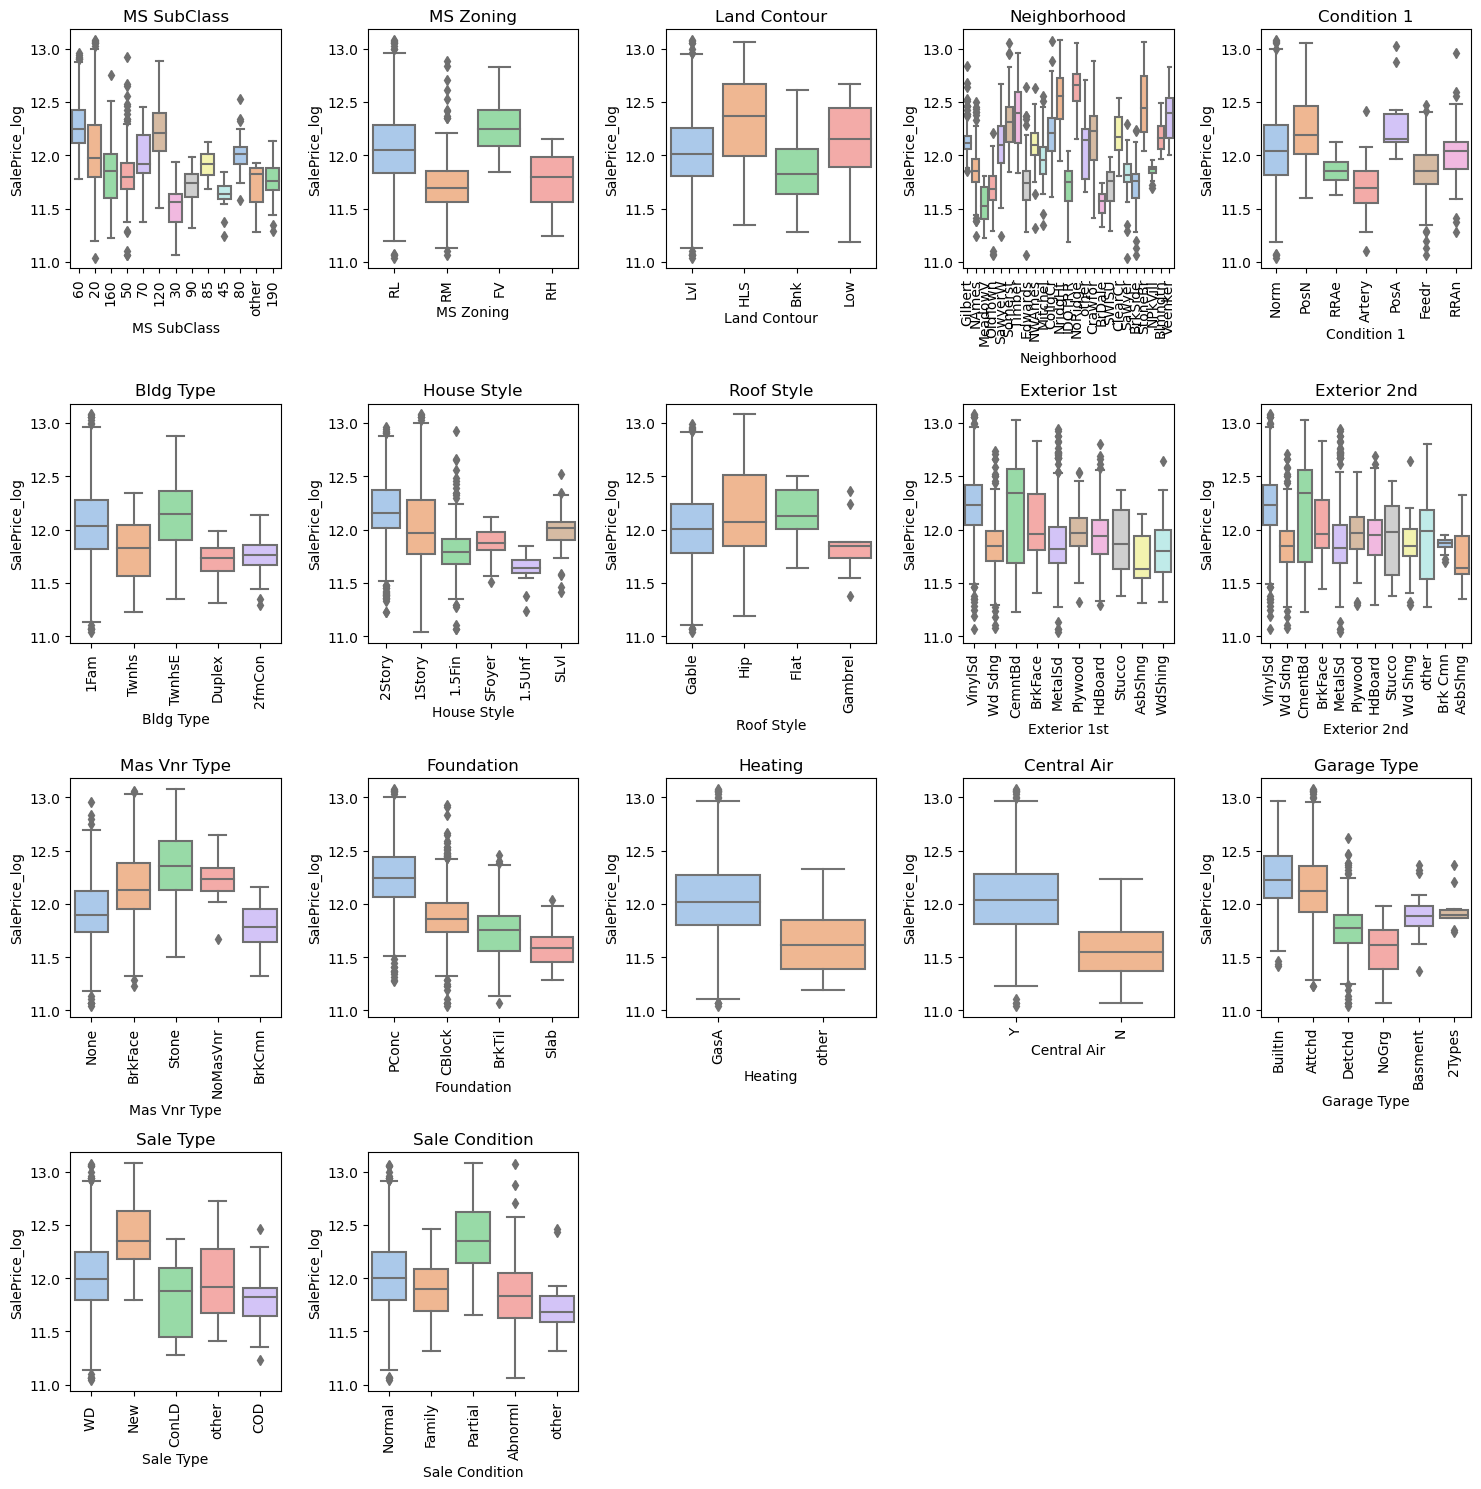

In [7]:
import math

n_rows = 4
n_cols = math.ceil(len(nom_col) / n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15,15))
axes = axes.flatten()

for ax, col in zip(axes, nom_col):
    sns.boxplot(data=df, x=col, y="SalePrice_log", ax=ax, palette = "pastel")
    ax.set_title(col)
    ax.tick_params("x", rotation=90)

# remove empty plots
for j in range(len(nom_col), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

By looking at this graph, it does look like one-hot encoding would work well for most of these variables. There is on exception: the feature **Central Air** which is a boolean feature (yes, no). We could already replace this feature with Y=1 and N=0. Let's start by doing this. 

### **1.1 Boolean encoding for the Central Air feature**

In [8]:
df["Central Air"] = df["Central Air"].map({
    "Y": 1,
    "N": 0 })

print(df["Central Air"].dtypes)

int64


In [9]:
print(df["Central Air"].value_counts())

1    1861
0      61
Name: Central Air, dtype: int64


It looks like this worked. Let's apply this to the test data set as well.

In [10]:
df_test["Central Air"] = df_test["Central Air"].map({
    "Y": 1,
    "N": 0 })

### **1.2 One Hot encoding for the other nominal features**
Let's now use one hot encoding for all other nominal features

In [11]:
nom_col = [col for col in nom_col if col != ["Central Air"]]

In [12]:
df = pd.get_dummies(data = df, columns = nom_col, drop_first=True)

In [13]:
df_test = pd.get_dummies(data=df_test, columns=nom_col, drop_first=True)

## **1. Encoding the ordinal features**
Let's use a different approach for the ordinal variables. Since most of the categories in these features can be ordered, we can define a number to each category and encode the feature in this way. Let's start by plotting our ordinal features and going through them one by one.

In [14]:
ord_cols = ["Lot Shape", "Overall Qual", "Overall Cond", "Exter Qual", 
           "Exter Cond", "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2",
           "Heating QC", "Electrical", "Kitchen Qual", "Functional", "Fireplace Qu", "Garage Finish", 
           "Garage Qual", "Garage Cond", "Paved Drive"]

In [15]:
df[ord_cols]

,Lot Shape,Overall Qual,Overall Cond,Exter Qual,Exter Cond,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin Type 2,Heating QC,Electrical,Kitchen Qual,Functional,Fireplace Qu,Garage Finish,Garage Qual,Garage Cond,Paved Drive
0,IR1,7,5,Gd,TA,Gd,TA,No,GLQ,Unf,Ex,SBrkr,Gd,Typ,TA,Fin,TA,TA,Y
1,Reg,6,6,TA,TA,TA,TA,No,Unf,Unf,TA,SBrkr,Gd,Typ,Gd,Unf,TA,TA,Y
2,Reg,4,5,TA,TA,TA,TA,No,Unf,Unf,Fa,SBrkr,TA,Typ,NoFireplace,Unf,TA,TA,Y
3,IR1,5,5,TA,TA,TA,TA,No,Rec,Unf,Gd,SBrkr,Gd,Typ,Gd,RFn,TA,TA,Y
4,Reg,5,8,TA,Gd,TA,TA,No,Unf,Unf,TA,SBrkr,TA,Typ,NoFireplace,Unf,Fa,TA,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1917,IR1,6,5,Gd,TA,Gd,TA,No,Unf,Unf,Ex,SBrkr,Gd,Typ,Gd,RFn,TA,TA,Y
1918,IR2,5,5,TA,Gd,Gd,TA,No,GLQ,Unf,Gd,SBrkr,Gd,Typ,NoFireplace,Unf,TA,TA,Y
1919,Reg,7,6,TA,TA,TA,TA,No,GLQ,Rec,TA,SBrkr,TA,Typ,TA,RFn,TA,TA,Y
1920,Reg,5,5,TA,TA,TA,TA,Av,ALQ,BLQ,TA,SBrkr,TA,Typ,Gd,RFn,TA,TA,Y


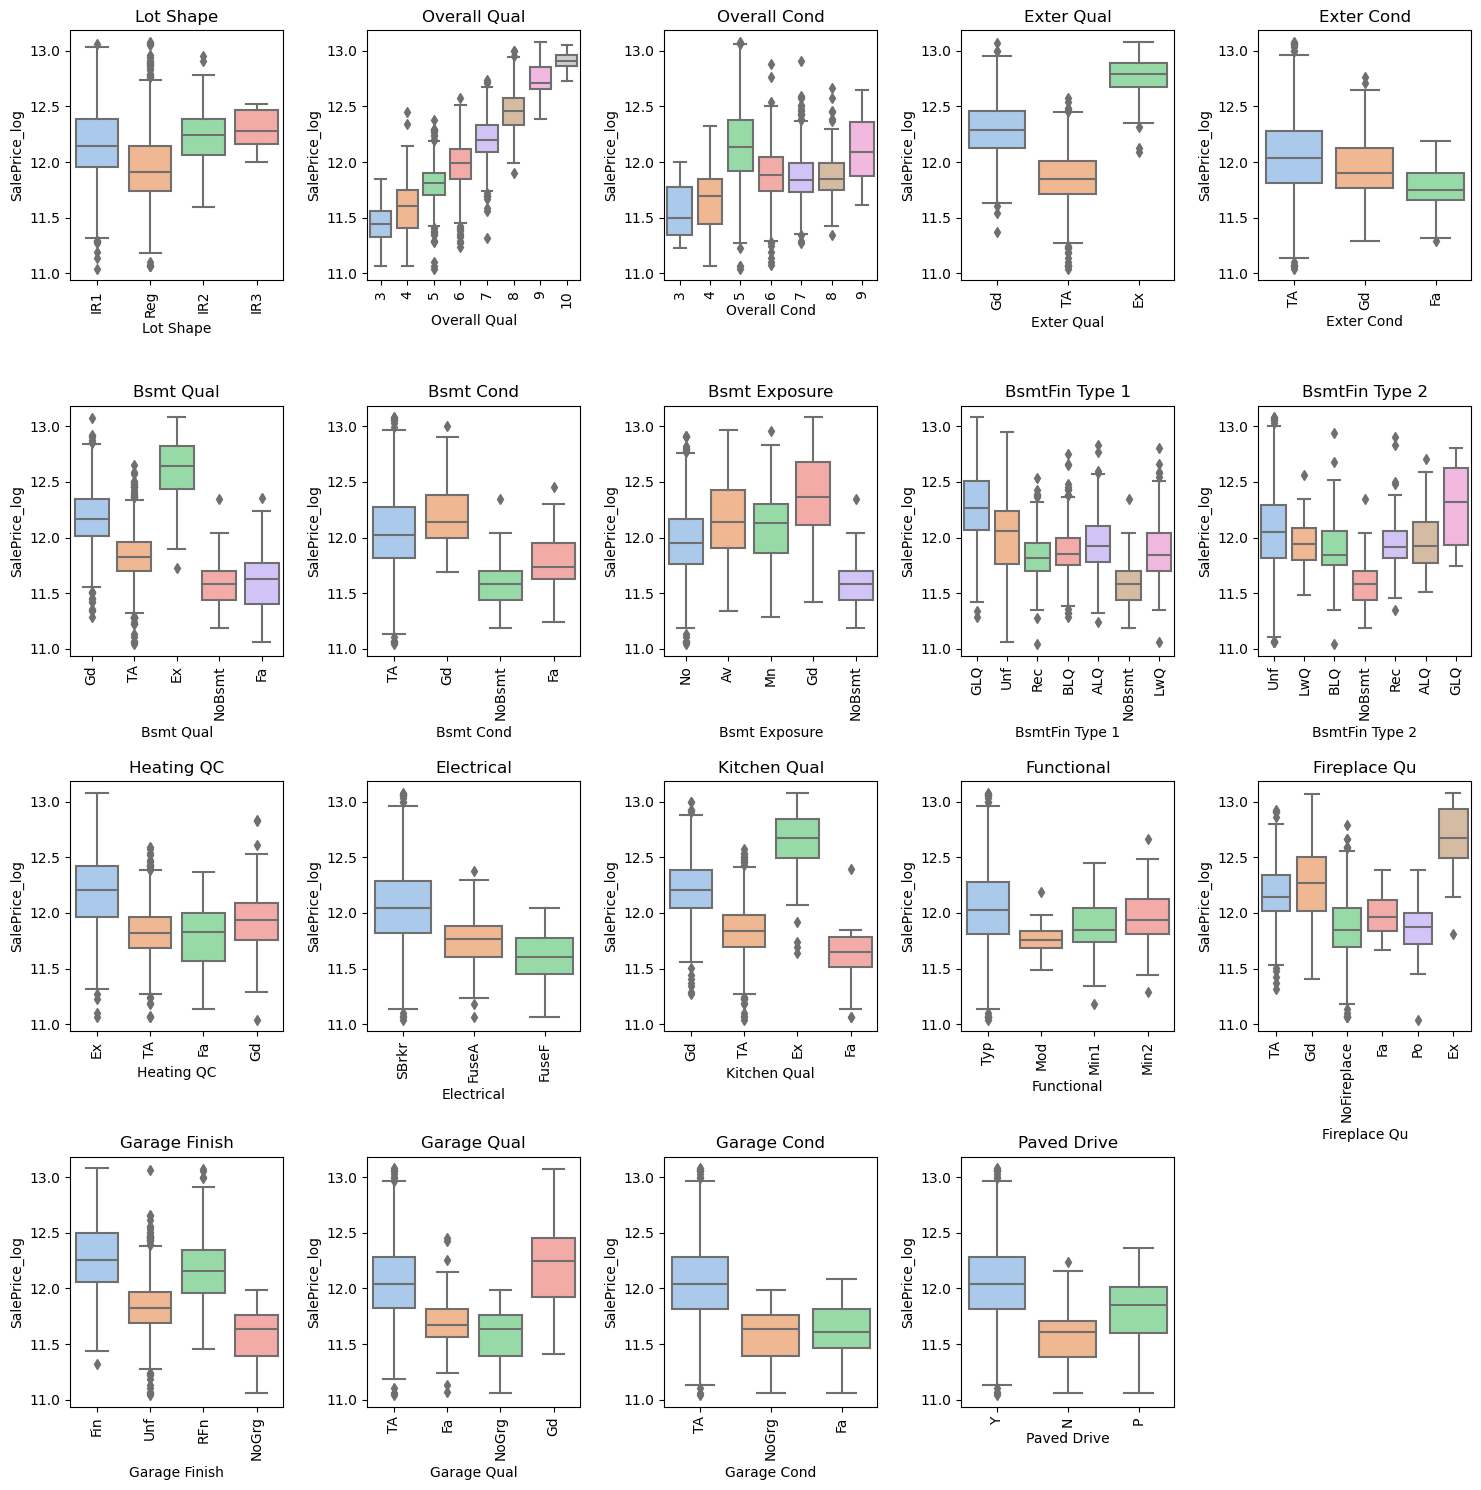

In [16]:
import math

n_rows = 4
n_cols = math.ceil(len(ord_cols) / n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15,15))
axes = axes.flatten()

for ax, col in zip(axes, ord_cols):
    sns.boxplot(data=df, x=col, y="SalePrice_log", ax=ax, palette = "pastel")
    ax.set_title(col)
    ax.tick_params("x", rotation=90)

# remove empty plots
for j in range(len(ord_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [17]:
df[ord_cols].dtypes

Lot Shape         object
Overall Qual       int64
Overall Cond       int64
Exter Qual        object
Exter Cond        object
Bsmt Qual         object
Bsmt Cond         object
Bsmt Exposure     object
BsmtFin Type 1    object
BsmtFin Type 2    object
Heating QC        object
Electrical        object
Kitchen Qual      object
Functional        object
Fireplace Qu      object
Garage Finish     object
Garage Qual       object
Garage Cond       object
Paved Drive       object
dtype: object

All right, we already see that two columns don't need to be encoded, the **Overall Qual** and **Overal Cond** columns are already integers. Let's encode the other columns one by one.

### **2.1 Encoding the "Quality" features**
To encode these columns, we can take inspiration from what was done for the **Overall Qual** feature.

In [18]:
df["Overall Qual"].value_counts()

5     548
6     501
7     434
8     236
4     115
9      67
3      12
10      9
Name: Overall Qual, dtype: int64

When looking at the documentation, we can read that the encoding for the **Overall Qual** feature was done as follows: 
- 10	Very Excellent
- 9	Excellent
- 8	Very Good
- 7	Good
- 6	Above Average
- 5	Average
- 4	Below Average
- 3	Fair
- 2	Poor
- 1	Very Poor

For a lot of the other features, we have this encoding (according to the documentation):
- Ex	Excellent
- Gd	Good
- TA	Average/Typical
- Fa	Fair
- Po	Poor
- NA	Non existant feature

To keep the two scales consistent, we could encode the features in this way:
- Ex: 9
- Gd: 7
- TA: 5
- Fa: 3
- Po: 2
- NA: 0

Let's apply this encoding to the following features:
- Exter Qual
- Bsmt Qual
- HeatingQC 
- Kitchen Qual
- Fireplace Qu
- Garage Qual

In [19]:
qual_cols = ["Exter Qual", "Bsmt Qual", "Heating QC", "Kitchen Qual", "Fireplace Qu", "Garage Qual"]

In [20]:
qual_mapping = {
    "Ex": 9,
    "Gd": 7,
    "TA": 5,
    "Fa": 3,
    "Po": 2,
    "NA": 0
}

df[qual_cols] = df[qual_cols].replace(qual_mapping)
df_test[qual_cols] = df_test[qual_cols].replace(qual_mapping)

For the Bsmt Cond and Garage Cond features, we still need to replace "NoGrg" and "NoBsmt" with 0. These where categories that I added manually to fill in the missing values.
Similarly, for the Fireplace Qu feature, we also need to replace "NoFireplace" with 0.

In [28]:
df["Bsmt Qual"] = df["Bsmt Qual"].replace({"NoBsmt": 0})
df["Garage Qual"] = df["Garage Qual"].replace({"NoGrg": 0})
df["Fireplace Qu"] = df["Fireplace Qu"].replace({"NoFireplace": 0})

df_test["Bsmt Qual"] = df_test["Bsmt Qual"].replace({"NoBsmt": 0})
df_test["Garage Qual"] = df_test["Garage Qual"].replace({"NoGrg": 0})
df_test["Fireplace Qu"] = df_test["Fireplace Qu"].replace({"NoFireplace": 0})

### **2.2 Encoding the "Condition" features**
A similar approach can be taken for the "condition" columns. Let's look at the possible values for the Overall Cond feature and create a mapping dictionary based on this feature. 

In [22]:
df["Overall Cond"].value_counts()

5    1163
6     373
7     236
8      80
4      41
3      18
9      11
Name: Overall Cond, dtype: int64

As before, when looking at the documentation, we can read that the encoding for the **Overall Cond** feature was done as follows: 
- 10	Very Excellent
- 9	Excellent
- 8	Very Good
- 7	Good
- 6	Above Average
- 5	Average
- 4	Below Average
- 3	Fair
- 2	Poor
- 1	Very Poor

For a lot of the other features, we have this encoding (according to the documentation):
- Ex	Excellent
- Gd	Good
- TA	Average/Typical
- Fa	Fair
- Po	Poor
- NA	Non existant feature

To keep the two scales consistent, we could encode the features in this way:
- Ex: 9
- Gd: 7
- TA: 5
- Fa: 3
- Po: 2
- NA: 0

Let's apply this encoding to the following features:
- Exter Cond
- Bsmt Cond
- Garage Cond

In [23]:
cond_cols = ["Exter Cond", "Bsmt Cond", "Garage Cond"]

In [24]:
cond_mapping = {
    "Ex": 9,
    "Gd": 7,
    "TA": 5,
    "Fa": 3,
    "Po": 2,
    "NA": 0
}

df[cond_cols] = df[cond_cols].replace(cond_mapping)
df_test[cond_cols] = df_test[cond_cols].replace(cond_mapping)

For the Bsmt Cond and Garage Cond features, we still need to replace "NoGrg" and "NoBsmt" with 0. 

In [25]:
df["Bsmt Cond"] = df["Bsmt Cond"].replace({"NoBsmt": 0})
df["Garage Cond"] = df["Garage Cond"].replace({"NoGrg": 0})

df_test["Bsmt Cond"] = df_test["Bsmt Cond"].replace({"NoBsmt": 0})
df_test["Garage Cond"] = df_test["Garage Cond"].replace({"NoGrg": 0})

Let's now check which other columns still need encoding.

In [29]:
df[ord_cols].dtypes

Lot Shape         object
Overall Qual       int64
Overall Cond       int64
Exter Qual         int64
Exter Cond         int64
Bsmt Qual          int64
Bsmt Cond          int64
Bsmt Exposure     object
BsmtFin Type 1    object
BsmtFin Type 2    object
Heating QC         int64
Electrical        object
Kitchen Qual       int64
Functional        object
Fireplace Qu       int64
Garage Finish     object
Garage Qual        int64
Garage Cond        int64
Paved Drive       object
dtype: object

We see that we still to have a look at the following features:
- Lot Shape
- Bsmt Exposure
- BsmtFin Type 1
- BsmtFin Type 2
- Electrical
- Functional
- Garage Finish
- Paved Drive

Let's have a look at the documentation for each of them.


### **2.3 Encoding the Lot Shape feature**
This is the documentation for this feature:
- Reg	Regular	
- IR1	Slightly irregular
- IR2	Moderately Irregular
- IR3	Irregular
       
Let's apply the following mapping (We will add the highest value to IR3 as when looking at the relationship to the sale price, houses with an irregular lot shape have a higher sale price):
- Reg: 1
- IR1: 2
- IR2: 3
- IR3: 4

In [31]:
df["Lot Shape"] = df["Lot Shape"].replace({
    "Reg": 1,
    "IR1": 2, 
    "IR2": 3,
    "IR3": 4}
)

In [32]:
df_test["Lot Shape"] = df_test["Lot Shape"].replace({
    "Reg": 1,
    "IR1": 2, 
    "IR2": 3,
    "IR3": 4}
)

In [33]:
df["Lot Shape"].value_counts()

1    1163
2     696
3      54
4       9
Name: Lot Shape, dtype: int64

### **2.4 Encoding the Bsmt Exposure Feature**
This is the documentation for this feature:
- Gd	Good Exposure
- Av	Average Exposure (split levels or foyers typically score average or above)	
- Mn	Mimimum Exposure
- No	No Exposure
- NA	No Basement

Let's apply the following mapping (houses with Bsmt Exposure = Gd have a higher sale price):
- NoBsmt: 0
- No: 1
- Mn: 2
- Av: 3
- Gd: 4


In [38]:
df["Bsmt Exposure"] = df["Bsmt Exposure"].replace({
    "NoBsmt": 0,
    "No": 1,
    "Mn": 2, 
    "Av": 3,
    "Gd": 4}
)

In [37]:
df_test["Bsmt Exposure"] = df_test["Bsmt Exposure"].replace({
    "NoBsmt": 0,
    "No": 1,
    "Mn": 2, 
    "Av": 3,
    "Gd": 4}
)

In [39]:
df["Bsmt Exposure"].value_counts()

1    1244
3     294
2     170
4     170
0      44
Name: Bsmt Exposure, dtype: int64

### **2.5 Encoding the BsmtFin Type Features**

These two features have the following categories:
- GLQ	Good Living Quarters
- ALQ	Average Living Quarters
- BLQ	Below Average Living Quarters	
- Rec	Average Rec Room
- LwQ	Low Quality
- Unf	Unfinshed
- NoBsmt	No Basement

Let's apply the following encoding:
- GLQ: 6
- ALQ: 5
- BLQ: 4
- Rec: 3
- LwQ: 2
- Unf: 1
- NoBsmt: 0

In [40]:
df[["BsmtFin Type 1", "BsmtFin Type 2"]] = df[["BsmtFin Type 1", "BsmtFin Type 2"]].replace({
    "NoBsmt": 0,
    "Unf": 1,
    "LwQ": 2, 
    "Rec": 3,
    "BLQ": 4,
    "ALQ": 5,
    "GLQ": 6
}
)

In [41]:
df_test[["BsmtFin Type 1", "BsmtFin Type 2"]] = df_test[["BsmtFin Type 1", "BsmtFin Type 2"]].replace({
    "NoBsmt": 0,
    "Unf": 1,
    "LwQ": 2, 
    "Rec": 3,
    "BLQ": 4,
    "ALQ": 5,
    "GLQ": 6
}
)

### **2.6 Encoding the Electrical Feature**
These are the categories for this feature:
- SBrkr	Standard Circuit Breakers & Romex
- FuseA	Fuse Box over 60 AMP and all Romex wiring (Average)	
- FuseF	60 AMP Fuse Box and mostly Romex wiring (Fair)
- FuseP	60 AMP Fuse Box and mostly knob & tube wiring (poor)
- Mix	Mixed

Let's plot this feature once more to better understand how we should encode the mix category.

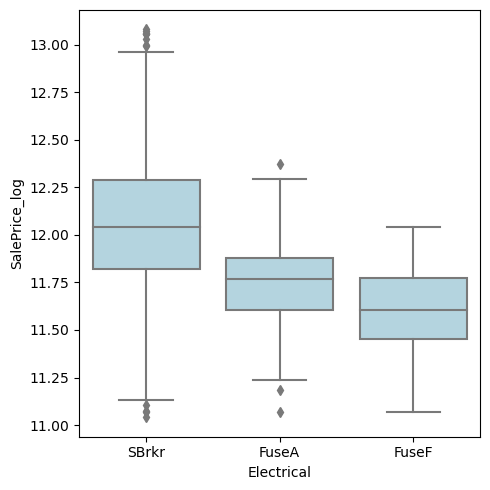

In [47]:
plt.figure(figsize=(5, 5))
sns.boxplot(data=df, x="Electrical", y="SalePrice_log", color="lightblue")
plt.tight_layout()
plt.show()


Interesting, the category "mix" was removed during data cleaning. It now becomes obvious how we can encode this feature based on the average category's sale price:
- SBrkr: 3
- FuseA: 2
- FuseF: 1

In [48]:
df["Electrical"] = df["Electrical"].replace({
    "FuseF": 1,
    "FuseA": 2, 
    "SBrkr": 3}
)

In [49]:
df_test["Electrical"] = df_test["Electrical"].replace({
    "FuseF": 1,
    "FuseA": 2, 
    "SBrkr": 3}
)

### **2.7 Encoding the Functional Feature**
These are the following categories:
- Typ	Typical Functionality
- Min1	Minor Deductions 1
- Min2	Minor Deductions 2
- Mod	Moderate Deductions
- Maj1	Major Deductions 1
- Maj2	Major Deductions 2
- Sev	Severely Damaged
- Sal	Salvage only

Let's encode this as follows:
- Typ: 8
- Min1: 7
- Min2: 6
- Mod: 5
- Maj1: 4
- Maj2: 3
- Sev: 2
- Sal: 1

In [ ]:
df["Functional"] = df["Functional"].replace({
    "Sal": 1,
    "Sev": 2, 
    "Maj2": 3,
    "Maj1": 4,
    "Mod": 5,
    "Min2": 6,
    "Min1": 7,
    "Typ": 8
}
)

In [53]:
df_test["Functional"] = df_test["Functional"].replace({
    "Sal": 1,
    "Sev": 2, 
    "Maj2": 3,
    "Maj1": 4,
    "Mod": 5,
    "Min2": 6,
    "Min1": 7,
    "Typ": 8
}
)

In [52]:
df["Functional"].value_counts()

8    1827
7      45
6      33
5      17
Name: Functional, dtype: int64

### **2.8 Encoding the Garage Finish Feature**
These are the categories:
- Fin	Finished
- RFn	Rough Finished	
- Unf	Unfinished
- NoGrg	No Garage

We can encode them as such (houses with a finished garage have a higher sale price):
- Fin : 3
- RFn: 2
- Unf: 1
- NoGrg: 0

In [57]:
df["Garage Finish"] = df["Garage Finish"].replace({
    "Unf": 1,
    "RFn": 2, 
    "Fin": 3,
    "NoGrg": 0,
}
)

In [58]:
df_test["Garage Finish"] = df_test["Garage Finish"].replace({
    "Unf": 1,
    "RFn": 2, 
    "Fin": 3,
    "NoGrg": 0,
}
)

In [59]:
df["Garage Finish"].value_counts()

1    778
2    597
3    489
0     58
Name: Garage Finish, dtype: int64

### **2.9 Encoding the Paved Drive Feature**

Finally we can encode the paved drive feature. This feature has the following categories:
- Y	Paved 
- P	Partial Pavement
- N	Dirt/Gravel

Based on the relationship to the sale price, we can encode this as follows:
- Y	3 
- P	2
- N	1

In [60]:
df["Paved Drive"] = df["Paved Drive"].replace({
    "N": 1,
    "P": 2, 
    "Y": 3
}
)

In [61]:
df_test["Paved Drive"] = df_test["Paved Drive"].replace({
    "N": 1,
    "P": 2, 
    "Y": 3
}
)

Let's now make sure our encoding strategy worked for all ordinal variables

In [63]:
df[ord_cols].dtypes

Lot Shape         int64
Overall Qual      int64
Overall Cond      int64
Exter Qual        int64
Exter Cond        int64
Bsmt Qual         int64
Bsmt Cond         int64
Bsmt Exposure     int64
BsmtFin Type 1    int64
BsmtFin Type 2    int64
Heating QC        int64
Electrical        int64
Kitchen Qual      int64
Functional        int64
Fireplace Qu      int64
Garage Finish     int64
Garage Qual       int64
Garage Cond       int64
Paved Drive       int64
dtype: object

In [64]:
df_test[ord_cols].dtypes

Lot Shape         int64
Overall Qual      int64
Overall Cond      int64
Exter Qual        int64
Exter Cond        int64
Bsmt Qual         int64
Bsmt Cond         int64
Bsmt Exposure     int64
BsmtFin Type 1    int64
BsmtFin Type 2    int64
Heating QC        int64
Electrical        int64
Kitchen Qual      int64
Functional        int64
Fireplace Qu      int64
Garage Finish     int64
Garage Qual       int64
Garage Cond       int64
Paved Drive       int64
dtype: object

This looks good! Before saving, let's make sure we don't need to encode any other feature in our data set.

In [66]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [67]:
df_test.select_dtypes(include='object').columns

Index([], dtype='object')

This looks good. Let's now save our data set.

## **3. Saving the data set**

In [68]:
df.to_csv("clean_df.csv", index=False)
df_test.to_csv("clean_df_test.csv", index=False)